In [1]:
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from datetime import datetime
import os
import numpy as np
import pywt
%matplotlib inline

In [2]:
os.chdir("../")

In [3]:
%pwd

'c:\\Users\\Rounak\\Desktop\\OneDrive\\College\\Projects\\Privacy-Preserving-Human-Pose-Estimation-from-WiFi'

In [4]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class DataTransformationConfig:
    root_dir: Path
    data_dir: Path

In [5]:
from PrivacyPreservingHumanPoseEstimationFromWiFi.utils.common import read_yaml, create_directories
from PrivacyPreservingHumanPoseEstimationFromWiFi.constants import *

In [6]:
class ConfigurationManager:
    def __init__(self, config_filepath = CONFIG_FILE_PATH, params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_data_transformation_config(self) -> DataTransformationConfig:
        config = self.config.data_transformation
        params = self.params.data_transformation
        create_directories([config.root_dir])

        data_transformation_config = DataTransformationConfig(
            root_dir = config.root_dir,
            data_dir = config.data_dir,
        )

        # data_transformation_params = DataTransformationParams(
        #     window_size = params.window_size,
        #     n_sigmas = params.n_sigmas,
        #     level = params.level,
        #     wavelet = params.wavelet,
        #     threshold = params.threshold,
        # )

        return data_transformation_config

In [9]:
class DataTransformation:
    def __init__(self, config: DataTransformationConfig):
        self.config = config
        self.subfolders = []
        self.files = {}
        self.activity_data = {}
        self.labels = []
        self.data = []
    
    def get_csi_files(self):
        self.subfolders = [f.path for f in os.scandir(self.config.data_dir) if f.is_dir()]
        self.subfolders = [f for f in self.subfolders if f.split('\\').pop().startswith('AR')]
        for subfolder in self.subfolders:
            self.files[subfolder.split('\\').pop()] = [f.path for f in os.scandir(subfolder) if f.is_file()]
            self.files[subfolder.split('\\').pop()] = [f.replace('\\', '/') for f in self.files[subfolder.split('\\').pop()]]
    
    def get_csi_data(self):
        self.get_csi_files()
        for folder, filepaths in self.files.items():
            print("Now working on folder: " + folder)
            for filepath in filepaths:
                mat_contents = sio.loadmat(filepath)
                csi_data = pd.DataFrame.from_dict(mat_contents['csi_buff'])
                filename = filepath.split('/').pop()

                csi_data = csi_data.applymap(lambda x: np.angle(x)) # Convert to phase

                self.activity_data[filename] = csi_data
        
        # self.activity_data = {k[5]: v for k, v in self.activity_data.items()}
    
    def linear_transform(self, phase):
        return (phase + np.pi) / (2 * np.pi)
    
    def hampel_filter(self, data, window_size=5, n_sigmas=3):
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        is_outlier = np.abs(data - median) > (n_sigmas * mad)
        data[is_outlier] = median  # Replace outliers with the median
        return data
    
    def denoise_signal(self, signal, level=3, wavelet='db4'):
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        threshold = 0.3 * np.max(coeffs[0])  # Adjust threshold as needed
        denoised_coeffs = [pywt.threshold(c, threshold) for c in coeffs]
        denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
        return denoised_signal

    def data_transformation(self):
        self.get_csi_data()
        for filename, data in self.activity_data.items():
            print("Performing data transformation on file: " + filename)
            for column in data:
                data[column] = self.linear_transform(data[column])
                data[column] = self.hampel_filter(data[column])
                data[column] = self.denoise_signal(data[column])
            self.activity_data[filename] = data
        
    def dict_to_list(self):
        for filename, data in self.activity_data.items():
            self.labels.append(filename[6])
            self.data.append(data.values.tolist())
        return self.data, self.labels
    
    def save_data(self):
        self.data_transformation()
        self.dict_to_list()
        print("Saving data...")
        np.save(self.config.root_dir / "data.npy", self.data)
        np.save(self.config.root_dir / "labels.npy", self.labels)
        print("Data saved successfully!")


In [10]:
try:
    config = ConfigurationManager()
    data_transformation_config = config.get_data_transformation_config()
    data_transformation = DataTransformation(config = data_transformation_config)
    data_transformation.save_data()

except Exception as e:
    raise e

[2023-10-20 20:53:49,315: INFO: common] Successfully read yaml file from config\config.yaml
[2023-10-20 20:53:49,323: INFO: common] Successfully read yaml file from params.yaml
[2023-10-20 20:53:49,326: INFO: common] Created directory at: artifacts
[2023-10-20 20:53:49,330: INFO: common] Created directory at: artifacts/data_transformation


Now working on folder: AR-1a
Now working on folder: AR-1b
Now working on folder: AR-1c
Now working on folder: AR-1d
Now working on folder: AR-1e
Now working on folder: AR-2a
Now working on folder: AR-3a
Now working on folder: AR-3b
Now working on folder: AR-4a
Now working on folder: AR-5a
Now working on folder: AR-5b


MemoryError: Unable to allocate 324. MiB for an array with shape (21217280,) and data type complex128

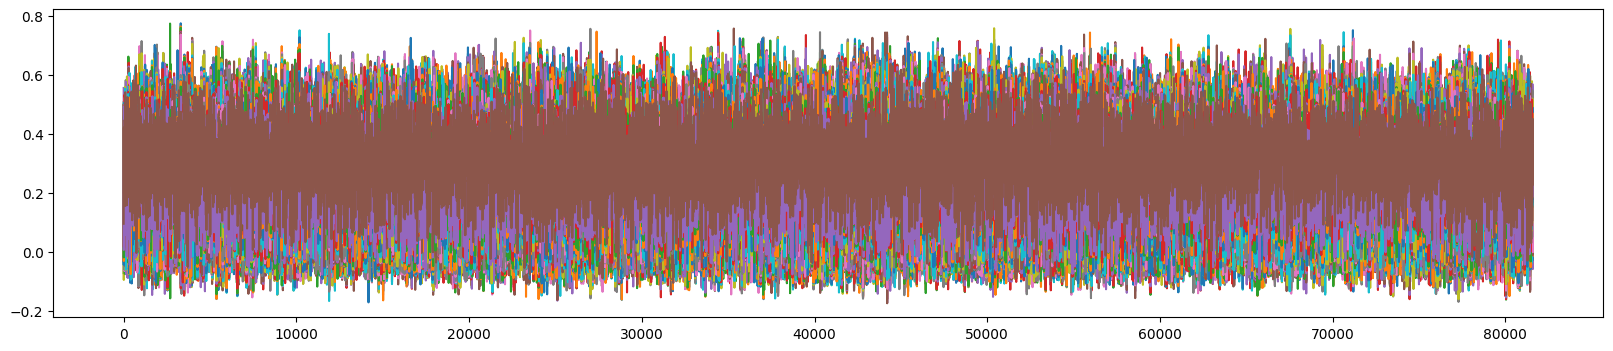

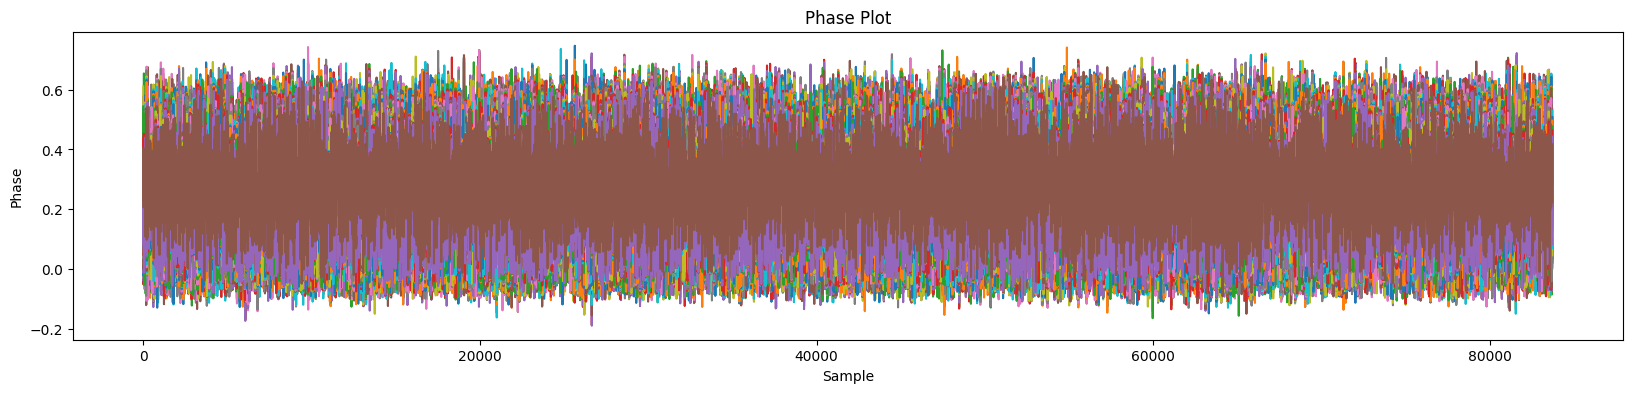

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.plot(data_transformation.activity_data['C'])
# plot one more data of key W
plt.figure(figsize=(20, 4))
plt.plot(data_transformation.activity_data['W'])
plt.title('Phase Plot')
plt.xlabel('Sample')
plt.ylabel('Phase')
plt.show()

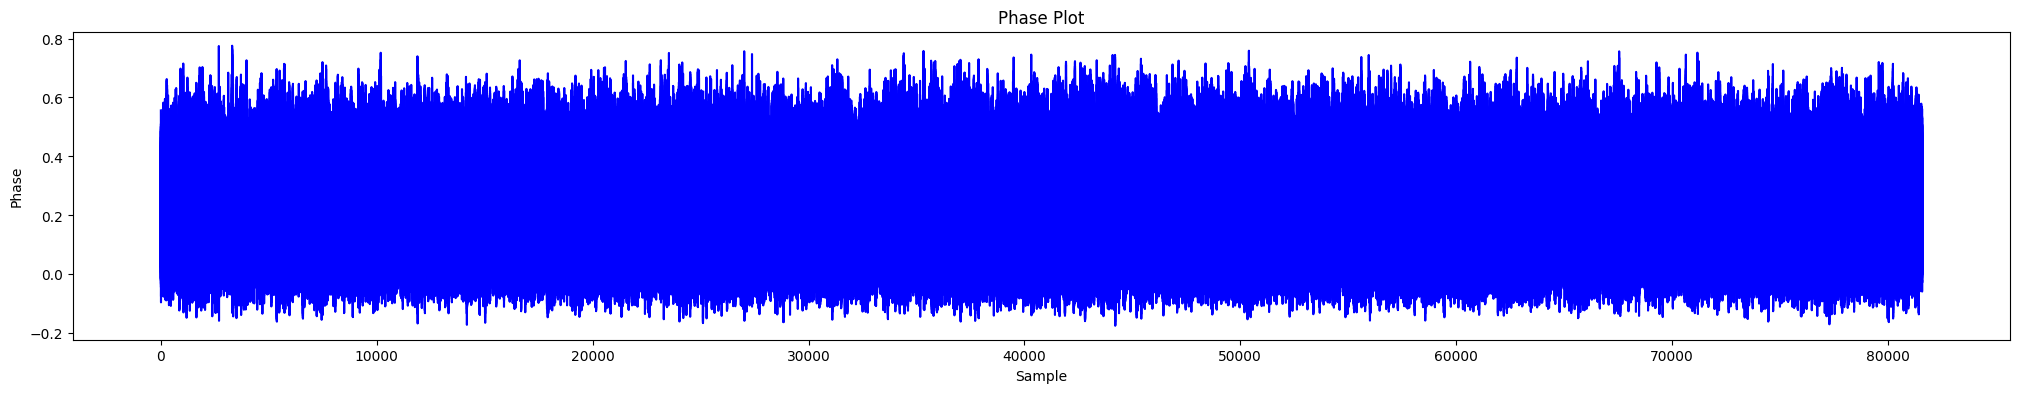

In [26]:
# single color plot
plt.figure(figsize=(25, 4))
plt.plot(data_transformation.activity_data['C'], color = 'blue')
plt.title('Phase Plot')
plt.xlabel('Sample')
plt.ylabel('Phase')
plt.show()

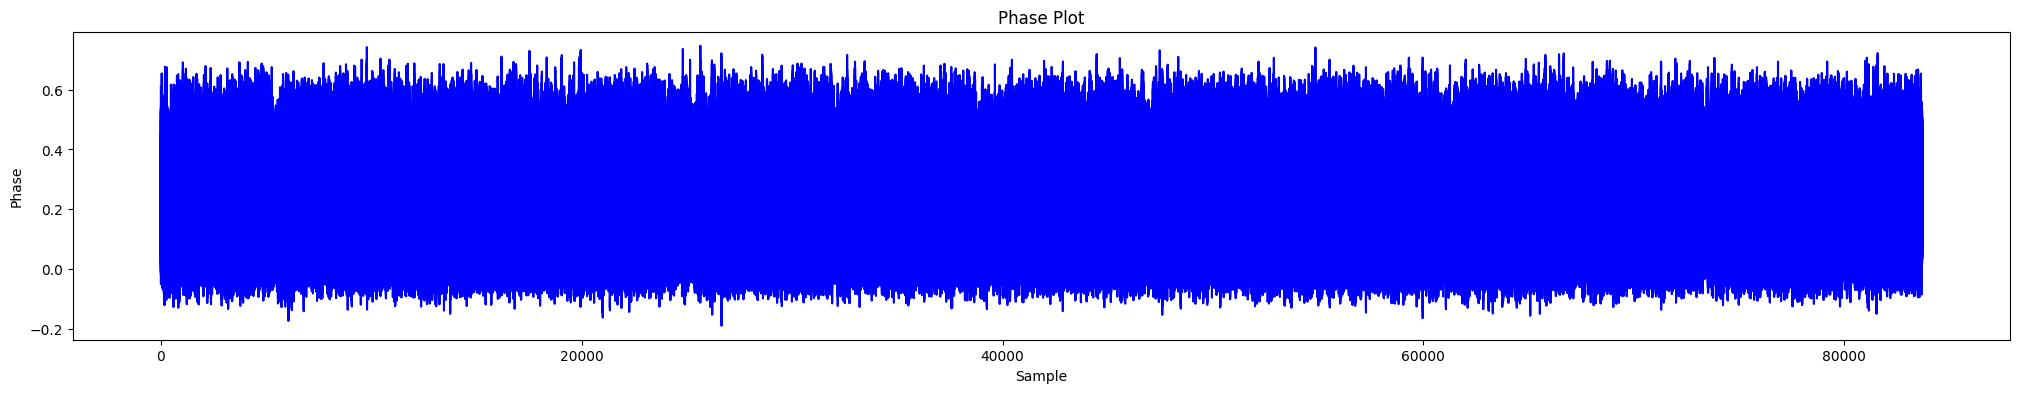

In [25]:
# single color plot
plt.figure(figsize=(25, 4))
plt.plot(data_transformation.activity_data['W'], color = 'blue')
plt.title('Phase Plot')
plt.xlabel('Sample')
plt.ylabel('Phase')
plt.show()